# Automatic ETL — AI-Assisted Data Cleansing and Preparation

## Project Overview

This notebook is the first stage of the **Rock Tools Performance Sourcing Strategy** for Americas Mining Corporation (AMC), covering mining operations in **Mexico, Peru, and the United States**.

The overall project aims to combine **data analytics, strategic sourcing, automation, and Artificial Intelligence** to evaluate drill bit performance, supplier performance, costs, quality, and operational efficiency, ultimately supporting data-driven sourcing and negotiation decisions.

The complete solution will address:

* Data extraction, cleansing, and preparation
* AI-assisted ETL automation
* Analytical data model design
* KPI development
* Exploratory Data Analysis
* Supplier and drill bit performance evaluation
* Strategic sourcing opportunities
* Risk and supplier assessment
* Python and AI-based analytics
* Automated reporting and executive insights
* End-to-end ETL and Power BI automation

---

## Notebook Scope

**`AutomaticETL.ipynb`** represents the initial **ETL (Extract, Transform, Load)** stage of the project, enhanced with an **AI Agent** to assist with data inspection, quality assessment, transformation planning, and ETL execution.

The main objective of this notebook is to transform the raw drilling-bit dataset into a reliable, standardized, and analysis-ready dataset for subsequent analytical processes.

The notebook will work with the source file:

**`DrillingBits.xlsx`**

The ETL process will extract the data from the Excel source and perform a structured assessment of its quality. An AI Agent will be used to assist in identifying potential data-quality issues, interpreting the structure and content of the dataset, and determining appropriate transformation actions.

The actual data transformations will be performed through controlled Python-based ETL functions and libraries such as **Pandas**, allowing the process to remain reproducible, traceable, and auditable.

---

## AI-Assisted ETL Approach

The purpose of the AI Agent is not to replace the ETL logic, but to provide an intelligent layer on top of the data-processing pipeline.

The agent will assist with tasks such as:

1. **Dataset Inspection**

   * Analyze the structure of the dataset.
   * Identify columns, data types, missing values, duplicates, and potential inconsistencies.
   * Examine basic statistical and categorical information.

2. **Data Quality Assessment**

   * Identify potential data-quality problems.
   * Detect inconsistent formats, invalid values, duplicated records, and potential anomalies.
   * Provide a structured description of the issues identified.

3. **Transformation Planning**

   * Determine which transformations may be required.
   * Propose appropriate cleansing and standardization actions.
   * Explain the rationale behind each proposed transformation.

4. **Controlled ETL Execution**

   * Invoke predefined Python/Pandas ETL functions.
   * Apply approved transformations to the dataset.
   * Maintain a clear separation between AI reasoning and actual data manipulation.

5. **Validation**

   * Re-evaluate the dataset after transformations.
   * Verify that identified issues were properly addressed.
   * Confirm that the resulting dataset meets the required quality standards.

6. **Documentation**

   * Maintain a record of detected issues and applied transformations.
   * Produce an interpretable summary of the ETL process and its results.

---

## ETL Process

The notebook will follow an iterative AI-assisted ETL workflow:

```text
Raw Excel File
      │
      ▼
    Extract
      │
      ▼
Dataset Inspection
      │
      ▼
 AI Agent Analysis
      │
      ▼
Data Quality Assessment
      │
      ▼
Transformation Plan
      │
      ▼
Controlled Python/Pandas ETL
      │
      ▼
Data Validation
      │
      ▼
Clean Analytical Dataset
```

The AI Agent will operate as an **intelligent orchestration and reasoning layer**, while deterministic Python/Pandas functions will perform the actual transformations.

This approach is intended to combine the flexibility of AI with the reproducibility and control required in a professional data-processing pipeline.

---

## Deliverable 1 — Data Cleansing and Preparation

**`AutomaticETL.ipynb`** addresses:

> **Deliverable 1 — Data Cleansing and Preparation**

### Deliverable Objective

Identify, document, and resolve relevant data-quality issues found in the raw dataset before performing KPI calculations, exploratory analysis, supplier comparisons, cost analysis, or strategic sourcing analysis.

The AI-assisted approach will help make the data-cleansing process more adaptive to the actual characteristics of the dataset rather than relying exclusively on a fixed set of predefined transformations.

---

## Expected Output

At the end of **`AutomaticETL.ipynb`**, we should have:

* A documented understanding of the raw dataset.
* A complete data-quality assessment.
* Identified and documented data-quality issues.
* An AI-generated transformation plan.
* Applied and traceable cleansing and standardization rules.
* Validation results confirming the quality of the transformed dataset.
* A clean and standardized dataset ready for:

  * Data Model Design
  * KPI Development
  * Exploratory Data Analysis
  * Supplier Performance Analysis
  * Drill Bit Performance Analysis
  * Cost Analysis
  * Strategic Sourcing Analysis

The resulting ETL process should also provide a foundation for future automation, allowing the AI Agent to assist with similar datasets and progressively support a more automated end-to-end data preparation workflow.


                 ┌──────────────────────┐
                 │       Usuario        │
                 │  XLS / CSV + objetivo │
                 └──────────┬───────────┘
                            │
                            ▼
                 ┌──────────────────────┐
                 │    GPT-OSS 20B       │
                 │       Agente         │
                 └──────────┬───────────┘
                            │
              ┌─────────────┼─────────────┐
              ▼             ▼             ▼
         Inspeccionar    Detectar      Proponer
         dataset         problemas     acciones
              │             │             │
              └─────────────┼─────────────┘
                            ▼
                 ┌──────────────────────┐
                 │       Pandas         │
                 │   ETL / Cleaning     │
                 └──────────┬───────────┘
                            │
                            ▼
                 ┌──────────────────────┐
                 │ Dataset limpio       │
                 │ + reporte de cambios │
                 └──────────────────────┘

## Requirements

In [1]:
%%capture
!pip install langchain langchain-groq

In [2]:
import langchain
import langchain_groq
print("LangChain:",langchain.__version__)
print("LangChain Groq:",langchain_groq.__version__)

LangChain: 1.3.18
LangChain Groq: 1.1.3


In [3]:
from pathlib import Path
import os, json
from dotenv import load_dotenv
from dataclasses import dataclass, field
from typing import List, Dict, Any, Optional
from datetime import datetime, timedelta
from google.colab import userdata
from langchain_groq import ChatGroq
from langchain.agents import create_agent
from langchain_core.tools import tool
import requests
from langchain_core.messages import HumanMessage, AIMessage, BaseMessage


#on Google colab
from google.colab import drive
drive.mount('/content/drive')


import pandas as pd

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


##  IA configuration Model selection (Groq connect)

"openai/gpt-oss-20b" is used because the problem does not initially require a massive model.

It primarily needs to handle:

- instruction interpretation;
- reasoning about quality issues;
- tool selection;
- parameter generation;
- explanation of transformations;
- user interaction;
- function/tool ​​calling.

gpt-oss-20b is specifically geared toward reasoning use cases and supports tool use/function calling, as well as structured JSON. Groq offers it on its platform with a context window of up to 131,072 tokens.

In [4]:
def setApiKey(keyinput="Colab"):
    # --- CASO 1: GOOGLE COLAB ---
    if keyinput == "Colab":
        try:
            from google.colab import userdata
            api_key = userdata.get('GROQ_API_KEY')
            if not api_key:
                raise ValueError("El secreto está vacío o no configurado.")
            os.environ["GROQ_API_KEY"] = api_key
            print("✅ ¡API Key de Groq cargada exitosamente desde tus Secrets de Colab!")
        except Exception as e:
            print("❌ ERROR: No se pudo cargar la API Key de Groq desde tus Secrets.")
            print("\nPara solucionar esto en Colab, sigue estos pasos:")
            print("1. Ve a la consola de Groq y crea una API Key.")
            print("2. En el menú de la izquierda de Colab, haz clic en el icono de la llave (🔑 Secrets).")
            print("3. Añade un nuevo secreto con el nombre exacto: GROQ_API_KEY")
            print("4. Pega tu clave en el valor y activa el interruptor de 'Acceso al cuaderno'.")
            print("5. Vuelve a ejecutar esta celda.")

    # --- CASO 2: ARCHIVO .ENV LOCAL ---
    elif keyinput == ".env":
        try:
            load_dotenv()
            api_key = os.environ.get("GROQ_API_KEY")
            if not api_key:
                raise ValueError("La variable GROQ_API_KEY no existe en el archivo ..env")
            print("✅ ¡API Key de Groq cargada exitosamente desde el archivo ..env!")
        except Exception as e:
            print("❌ ERROR: No se encontró la API Key de Groq en tu entorno local.")
            print("\nPara solucionar esto en tu entorno local, sigue estos pasos:")
            print("1. Ve a la consola de Groq y crea una API Key.")
            print("2. Crea un archivo llamado '..env' en la raíz de tu proyecto.")
            print("3. Guarda tu clave escribiendo exactamente: GROQ_API_KEY=tu_clave_aqui")
            print("4. Vuelve a ejecutar esta celda.")

    # --- CASO 3: PASAR LA CLAVE COMO TEXTO DIRECTO ---
    else:
        os.environ["GROQ_API_KEY"] = keyinput
        print("✅ ¡API Key de Groq configurada directamente en las variables de entorno!")


setApiKey("Colab")

✅ ¡API Key de Groq cargada exitosamente desde tus Secrets de Colab!


In [5]:

#confirm model to use
def selecModel(modelName=  'openai/gpt-oss-20b'):
  try:
    api_key = os.environ.get("GROQ_API_KEY")
    url = "https://api.groq.com/openai/v1/models"

    headers = {
        "Authorization": f"Bearer {api_key}",
        "Content-Type": "application/json"
    }
    response = requests.get(url, headers=headers)

    for model in response.json()['data']:
      if model['id'] == modelName:
        return model

    raise ValueError(f"El modelo {modelName} no está disponible.")

  except Exception as e:
        print(f"❌ ERROR: {e}")

currentModel = selecModel()


## Agent configuration

The agent needs to understand that it is an ETL assistant, not simply a general chatbot.

The really important part is that df lives in Python, not inside the LLM.

The agent doesn't need to receive the entire Excel file as text.

In [6]:
#this is to be save on config file on production
SYSTEM_PROMPT = """
You are an AI agent specialized in ETL, data quality assessment,
data cleansing, and data preparation.

Your objective is to assist the user in transforming raw CSV and
Excel datasets into reliable, standardized, and analysis-ready
datasets.

You operate on a current ETL dataset and have access to controlled
ETL tools.

IMPORTANT PRINCIPLES:

1. Always inspect the dataset before proposing transformations.

2. Never assume column names, data types, formats, or values.

3. Use the available tools to investigate the dataset.

4. Do not modify data unless a transformation tool is explicitly
   available and appropriate.

5. Never invent data or business rules.

6. Every relevant data-quality issue identified during the ETL
   process must be recorded in the Data Quality Log.

7. Distinguish clearly between:
   - issues identified,
   - transformations proposed,
   - transformations executed,
   - transformations validated.

8. When an issue is identified, record:
   - affected column,
   - issue type,
   - description,
   - affected rows when available,
   - proposed action,
   - current status.

9. After a transformation is executed, update the corresponding
   issue status appropriately.

10. Use previous tool results and the current ETL state to avoid
    repeating work unnecessarily.

ETL WORKFLOW:

Extract
→ Inspect
→ Detect data-quality issues
→ Record issues in Data Quality Log
→ Plan transformations
→ Execute controlled transformations
→ Update Data Quality Log
→ Validate results
→ Generate quality report
→ Export clean dataset

The Data Quality Log is the authoritative record of data-quality
issues identified during the ETL process.

The process history records the sequence of ETL operations executed.

Be concise, precise, transparent, and explain important decisions.
"""

In [7]:
def createAgent(currentModel, curr_tools, init_prompt):
    """
    Creates the AI-powered ETL agent.

    Parameters
    ----------
    currentModel : str
        Groq model ID.

    curr_tools : list
        List of tools available to the agent.

    init_prompt : str
        Initial prompt for the agent.

    Returns
    -------
    agent
        Configured LangChain agent.
    """

    try:

        llm = ChatGroq(
              model=currentModel,
              temperature=0,
              max_tokens=2048,
              reasoning_effort="low"
          )

        agent = create_agent(
            model=llm,
            tools=curr_tools,
            system_prompt=init_prompt
        )

        return agent

    except Exception as e:
        print(f"❌ ERROR creating agent: {e}")
        return None

###  Tools development

In [8]:

@tool
def inspect_dataset() -> dict:
    """
    Inspects a pandas DataFrame and returns a structured dataset profile.

    The tool does not modify the dataset. It provides information about
    the dataset structure, columns, data types, missing values, duplicates,
    unique values, and basic statistics.

    into the first version:
    we want this tool to provide a compact dataset profile.
    Later we can create more specialized tools for numerical statistics,
    categorical analysis, outliers, etc.
    """

    try:
        df =  etl_context.df
        profile = {
            "shape": {
                "rows": int(df.shape[0]),
                "columns": int(df.shape[1])
            },

            "columns": [],

            "duplicates": {
                "count": int(df.duplicated().sum())
            },

            "memory_usage_mb": round(
                df.memory_usage(deep=True).sum() / (1024 ** 2), 2
            )
        }

        for column in df.columns:

            column_info = {
                "name": str(column),
                "dtype": str(df[column].dtype),
                "missing_values": int(df[column].isna().sum()),
                "missing_percentage": round(
                    df[column].isna().mean() * 100, 2
                ),
                "unique_values": int(df[column].nunique(dropna=True))
            }

            # Add sample values or unique

            min_sample_size = int(.03 * len(df[column].dropna()))
            if len(df[column].unique()) < min_sample_size:
              column_info["sample_values"] = (
                  df[column]
                  .dropna()
                  .unique()
                  .tolist()
              )
            else:
              column_info["sample_values"] = (
                  df[column]
                  .dropna()
                  .sample(min_sample_size)
                  .tolist()
              )

            profile["columns"].append(column_info)

        return profile

    except Exception as e:
        return {
            "error": str(e)
        }


#--------------------------------------------------------


@tool
def detect_missing_values() -> dict:
    """
    Detects missing values in the current ETL dataset.

    Returns all columns containing missing values and the number
    and percentage of affected rows.

    Each detected issue is registered in etl_context.dq_log.
    This tool does not modify the dataset.
    """

    try:

        df = etl_context.df

        missing = df.isna().sum()
        missing = missing[missing > 0]

        results = {
            "tool": "detect_missing_values",
            "columns_with_missing_values": []
        }

        if missing.empty:

            return {
                "tool": "detect_missing_values",
                "columns_with_missing_values": [],
                "message": "No missing values detected."
            }

        for column, count in missing.items():

            percentage = round(
                (count / len(df)) * 100,
                2
            )

            issue = {
                "column": str(column),
                "missing_values": int(count),
                "missing_percentage": percentage
            }

            results["columns_with_missing_values"].append(issue)

            etl_context.log_issue(
                record_type="issue",
                tool="detect_missing_values",
                column=str(column),
                issue_type="Missing values",
                description=(
                    f"Column contains {int(count)} missing values "
                    f"({percentage}% of rows)."
                ),
                affected_rows=int(count),
                action=(
                    "Investigate and apply an appropriate "
                    "missing-value treatment."
                ),
                status="Identified"
            )

        return results

    except Exception as e:

        return {
            "tool": "detect_missing_values",
            "error": str(e)
        }

#--------------------------------------------------------

@tool
def solve_missing_values(
    column: str,
    strategy: str
) -> dict:
    """
    Resolves missing values in a specified column.

    Supported strategies:
    - drop
    - mean
    - median
    - mode

    The tool modifies the current ETL dataset and records
    the resolution in etl_context.dq_log.
    """

    try:

        df = etl_context.df

        # --------------------------------
        # VALIDATE COLUMN
        # --------------------------------

        if column not in df.columns:

            return {
                "tool": "solve_missing_values",
                "error": f"Column '{column}' does not exist."
            }

        # --------------------------------
        # CHECK MISSING VALUES
        # --------------------------------

        missing_count = int(df[column].isna().sum())

        if missing_count == 0:

            return {
                "tool": "solve_missing_values",
                "column": column,
                "message": "No missing values found."
            }

        strategy = strategy.lower().strip()

        # --------------------------------
        # APPLY STRATEGY
        # --------------------------------

        if strategy == "drop":

            etl_context.df = (
                df.dropna(subset=[column])
                .reset_index(drop=True)
            )

            action = (
                f"Removed rows containing missing values "
                f"in column '{column}'."
            )

        elif strategy == "mean":

            if not pd.api.types.is_numeric_dtype(df[column]):

                return {
                    "tool": "solve_missing_values",
                    "error": (
                        f"Strategy 'mean' cannot be applied "
                        f"to non-numeric column '{column}'."
                    )
                }

            value = df[column].mean()

            etl_context.df[column] = (
                df[column].fillna(value)
            )

            action = (
                f"Filled missing values using the mean "
                f"({value})."
            )

        elif strategy == "median":

            if not pd.api.types.is_numeric_dtype(df[column]):

                return {
                    "tool": "solve_missing_values",
                    "error": (
                        f"Strategy 'median' cannot be applied "
                        f"to non-numeric column '{column}'."
                    )
                }

            value = df[column].median()

            etl_context.df[column] = (
                df[column].fillna(value)
            )

            action = (
                f"Filled missing values using the median "
                f"({value})."
            )

        elif strategy == "mode":

            mode = df[column].mode()

            if mode.empty:

                return {
                    "tool": "solve_missing_values",
                    "error": (
                        f"Could not determine mode "
                        f"for column '{column}'."
                    )
                }

            value = mode.iloc[0]

            etl_context.df[column] = (
                df[column].fillna(value)
            )

            action = (
                f"Filled missing values using the mode "
                f"({value})."
            )

        else:

            return {
                "tool": "solve_missing_values",
                "error": (
                    f"Unsupported strategy '{strategy}'. "
                    "Use: drop, mean, median or mode."
                )
            }

        # --------------------------------
        # VERIFY RESULT
        # --------------------------------

        remaining_missing = int(
            etl_context.df[column].isna().sum()
        )

        status = (
            "Resolved"
            if remaining_missing == 0
            else "Partially Resolved"
        )

        # --------------------------------
        # RECORD RESOLUTION IN DQ LOG
        # --------------------------------

        etl_context.log_issue(
            record_type="process",
            tool="solve_missing_values",
            column=column,
            issue_type="Missing values",
            description=(
                f"Resolved missing values in column '{column}'. "
                f"{missing_count} missing values were detected "
                f"before the transformation."
            ),
            affected_rows=missing_count,
            action=action,
            status=status
        )

        # --------------------------------
        # RETURN RESULT
        # --------------------------------

        return {
            "tool": "solve_missing_values",
            "column": column,
            "strategy": strategy,
            "missing_values_before": missing_count,
            "missing_values_after": remaining_missing,
            "status": status
        }

    except Exception as e:

        return {
            "tool": "solve_missing_values",
            "error": str(e)
        }



@tool
def save_df(filename: str = "clean_dataset.xlsx") -> dict:
    """
    Saves the current ETL dataset to an Excel .xlsx file
    in the current working directory.

    The tool does not modify the dataset.
    """

    try:

        # Current working directory
        output_path = Path.cwd() / filename

        # Ensure .xlsx extension
        if output_path.suffix.lower() != ".xlsx":
            output_path = output_path.with_suffix(".xlsx")

        # Current dataset
        df = etl_context.df

        # Save Excel file
        df.to_excel(
            output_path,
            index=False
        )

        # Register operation in ETL log
        etl_context.log_issue(
            record_type="process",
            tool="save_df",
            column=None,
            issue_type="Export",
            description=(
                f"Clean dataset exported successfully to "
                f"'{output_path.name}'."
            ),
            affected_rows=len(df),
            action=f"Save dataset as Excel file: '{output_path.name}'.",
            status="Completed"
        )

        return {
            "tool": "save_df",
            "status": "Completed",
            "file": output_path.name,
            "path": str(output_path),
            "rows": int(len(df)),
            "columns": int(len(df.columns))
        }

    except Exception as e:

        return {
            "tool": "save_df",
            "status": "Failed",
            "error": str(e)
        }
#-----------------------------------------------

@tool
def save_etl_context_log(filename: str = "dq_log.xlsx") -> dict:
    """
    Saves the current ETL Data Quality Log as an Excel file
    in the current working directory.
    """
    try:
        output_path = Path.cwd() / filename

        if output_path.suffix.lower() != ".xlsx":
            output_path = output_path.with_suffix(".xlsx")

        dq_log_df = pd.DataFrame(
            etl_context.dq_log
        )

        dq_log_df.to_excel(
            output_path,
            index=False
        )

        return {
            "tool": "save_etl_context_log",
            "status": "Completed",
            "file": output_path.name,
            "path": str(output_path),
            "entries": int(len(etl_context.dq_log))
        }

    except Exception as e:
        return {
            "tool": "save_etl_context_log",
            "status": "Failed",
            "error": str(e)
        }


#test tools
#profile = inspect_dataset.invoke({})

"""
curr_tools = [
    inspect_dataset,
    detect_missing_values,
    detect_duplicates,
    detect_outliers,
    detect_Inconsistent_formatting,
    detect_Mixed_data_types,
    normalize_column,
    convert_datatype,
    remove_duplicates,
    export_clean_dataset,
    solve_Inconsistent_formatting,
    solve_Mixed_data_types,
    solve_quality_issues,
    generate_quality_report,
    generate_log_process,
    save_df,
    save_etl_context_log
]
"""

#List of all tools avalible
TOOLS = [inspect_dataset,detect_missing_values, solve_missing_values, save_df,save_etl_context_log]

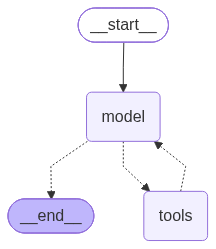

In [9]:
# Agent completed definition

currentAgent = createAgent(currentModel['id'], TOOLS , SYSTEM_PROMPT)

currentAgent

## Create the ETL Context

This class is designed to centralize all information related to the ETL process, ensuring a clean and organized architecture.

#### Architectural Components:

*   **`ETLContext` / State**: Manages the current DataFrame (`df`), the Data Quality Log (`dq_log`), and the `process_history`.
*   **ETL Tools**: Functions that inspect or modify the `ETLContext` state and record actions in the log.
*   **Agent History**: Preserves the conversation and tool-call history, allowing the agent to track previous steps.
*   **`run_agent()`**: Executes the agent's actions while maintaining the conversational context.
*   **`generate_quality_report()`**: Converts the `dq_log` into a pandas DataFrame upon request, providing a structured report.

```mermaid
graph TD
    A[ETL STATE] --> B[df]
    B --> B1[Current DataFrame]
    A --> C[dq_log]
    C --> C1[Data Quality Log]
    A --> D[process_history]
    D --> D1[ETL execution history]
```

In [10]:
@dataclass
class ETLContext:

    df: pd.DataFrame

    dq_log: list[dict[str, Any]] = field(default_factory=list)

    def log_issue(
        self,
        record_type: str,
        tool: str,
        column: str | None,
        issue_type: str,
        description: str,
        affected_rows: int | None,
        action: str,
        status: str = "Identified"
    ):

        entry = {
            "id": len(self.dq_log) + 1,
            "timestamp": datetime.now().isoformat(timespec="seconds"),
            "record_type": record_type,
            "tool": tool,
            "column": column,
            "issue_type": issue_type,
            "description": description,
            "affected_rows": affected_rows,
            "action": action,
            "status": status
        }

        self.dq_log.append(entry)

In [11]:
#instance of etl
df = pd.read_excel('/content/drive/MyDrive/GrupoMexicoTest/DrillingBits.xlsx')
etl_context = ETLContext(df=df)

## run Agent

In [12]:
history: list[BaseMessage] = []

def run_agent(
    user_input: str,
    history: list[BaseMessage],
    agent
):
    try:
        messages = history + [
            HumanMessage(content=user_input)
        ]

        result = agent.invoke(
            {"messages": messages},
            config={"recursion_limit": 50}
        )

        history.clear()
        history.extend(result["messages"])

        return result

    except Exception as e:
        return {
            "messages": [
                AIMessage(content=f"Error: {str(e)}")
            ]
        }


In [13]:
response = run_agent(
    "Inspect the current dataset. detect missing values and fix if necesary",
    history,
    currentAgent
)

In [14]:
for i, message in enumerate(response["messages"]):

    print(f"\n===== MESSAGE {i} =====")
    print("TYPE:", type(message).__name__)
    print("CONTENT:", message.content)


===== MESSAGE 0 =====
TYPE: HumanMessage
CONTENT: Inspect the current dataset. detect missing values and fix if necesary, repeat process until confirm no missing values

===== MESSAGE 1 =====
TYPE: AIMessage
CONTENT: 

===== MESSAGE 2 =====
TYPE: ToolMessage
CONTENT: {"shape": {"rows": 518, "columns": 11}, "columns": [{"name": "MINA", "dtype": "object", "missing_values": 0, "missing_percentage": 0.0, "unique_values": 2, "sample_values": ["BVC", "MDC"]}, {"name": "AÑO", "dtype": "int64", "missing_values": 0, "missing_percentage": 0.0, "unique_values": 1, "sample_values": [2026]}, {"name": "MES", "dtype": "object", "missing_values": 0, "missing_percentage": 0.0, "unique_values": 14, "sample_values": ["ENERO", "FEBRERO", "MARZO", "ABRIL", "MAYO", "JUNIO", "JULIO", "Enero", "Febrero", "Marzo", "Aabril", "Mayo", "Junio", "Julio"]}, {"name": "EQUIPO", "dtype": "int64", "missing_values": 0, "missing_percentage": 0.0, "unique_values": 26, "sample_values": [48, 44, 49, 37, 931, 831, 64, 931, 4

In [15]:
print(response['messages'][-1].content)

**ETL Process Summary**

| Step | Action | Result |
|------|--------|--------|
| 1 | Inspect dataset | 518 rows × 11 columns; 4 duplicates; missing values in 3 columns |
| 2 | Detect missing values | `FECHA DE DESCARTE` (10), `RECORRIDO (m)` (4), `Precio ` (3) |
| 3 | Resolve missing values | `FECHA DE DESCARTE` – dropped rows (10) <br> `Precio ` – imputed with column mean (3) |
| 4 | Re‑detect missing values | Only `RECORRIDO (m)` still had 4 missing values |
| 5 | Resolve remaining missing | `RECORRIDO (m)` – dropped rows (4) |
| 6 | Final check | No missing values remain |

**Data Quality Log**

| Column | Issue Type | Description | Affected Rows | Proposed Action | Current Status |
|--------|------------|-------------|---------------|-----------------|----------------|
| FECHA DE DESCARTE | Missing | 10 rows with null | 10 | Drop rows | Resolved |
| Precio  | Missing | 3 rows with null | 3 | Mean imputation | Resolved |
| RECORRIDO (m) | Missing | 4 rows with null | 4 | Drop rows |

In [16]:
etl_context.dq_log

[{'id': 1,
  'timestamp': '2026-09-17T03:35:14',
  'record_type': 'issue',
  'tool': 'detect_missing_values',
  'column': 'FECHA DE DESCARTE',
  'issue_type': 'Missing values',
  'description': 'Column contains 10 missing values (1.93% of rows).',
  'affected_rows': 10,
  'action': 'Investigate and apply an appropriate missing-value treatment.',
  'status': 'Identified'},
 {'id': 2,
  'timestamp': '2026-09-17T03:35:14',
  'record_type': 'issue',
  'tool': 'detect_missing_values',
  'column': 'RECORRIDO (m)',
  'issue_type': 'Missing values',
  'description': 'Column contains 4 missing values (0.77% of rows).',
  'affected_rows': 4,
  'action': 'Investigate and apply an appropriate missing-value treatment.',
  'status': 'Identified'},
 {'id': 3,
  'timestamp': '2026-09-17T03:35:14',
  'record_type': 'issue',
  'tool': 'detect_missing_values',
  'column': 'Precio ',
  'issue_type': 'Missing values',
  'description': 'Column contains 3 missing values (0.58% of rows).',
  'affected_rows': 

In [17]:
etl_context.df.isna().sum()

,0
MINA,0
AÑO,0
MES,0
EQUIPO,0
FECHA DE INGRESO,0
FECHA DE DESCARTE,0
MARCA,0
MEDIDA,0
RECORRIDO (m),0
RAZÓN DE DESCARTE,0


In [18]:
for h in history:
  print(h)

content='Inspect the current dataset. detect missing values and fix if necesary, repeat process until confirm no missing values' additional_kwargs={} response_metadata={} id='deb33e18-5312-4d2b-af00-7e5dad7545f0'
content='' additional_kwargs={'reasoning_content': 'We need to call inspect_dataset.', 'tool_calls': [{'id': 'fc_824a9785-5f8e-4bec-bac6-54b558867b59', 'function': {'arguments': '{}', 'name': 'inspect_dataset'}, 'type': 'function'}]} response_metadata={'token_usage': {'completion_tokens': 27, 'prompt_tokens': 818, 'total_tokens': 845, 'completion_time': 0.027306133, 'completion_tokens_details': {'reasoning_tokens': 8}, 'prompt_time': 0.043657978, 'prompt_tokens_details': None, 'queue_time': 0.092680913, 'total_time': 0.070964111}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_66f3850a1a', 'service_tier': 'on_demand', 'reasoning_effort': 'low', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'} id='lc_run--01a0ad6e-c454-7ff0-8426-1adf2afd

In [19]:
result = save_df.invoke({})
print(result)

{'tool': 'save_df', 'status': 'Completed', 'file': 'clean_dataset.xlsx', 'path': '/content/clean_dataset.xlsx', 'rows': 508, 'columns': 11}


In [20]:
result = save_etl_context_log.invoke({})
print(result)

{'tool': 'save_etl_context_log', 'status': 'Completed', 'file': 'dq_log.xlsx', 'path': '/content/dq_log.xlsx', 'entries': 7}
